# Thread 2: Gender Injustice
## Part 2

### Continuation from part 1. Files **csv4** to **csv7**.


## Analysis

# Importing Libraries

In [1]:
import sys
sys.path.append("..")
import utility as u
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
importlib.reload(u)

<module 'utility' from '/Users/bhavya/Documents/DS/The Committee Will Look Into It/02_Gender_Injustice/../utility.py'>

## Loading Data files

In [2]:
csv1= u.load_data("data/cleaned/file1.csv")
csv2= u.load_data("data/cleaned/file2.csv")
csv3= u.load_data("data/cleaned/file3.csv")
csv4= u.load_data("data/cleaned/file4.csv")
csv5= u.load_data("data/cleaned/file5.csv")
csv6= u.load_data("data/cleaned/file6.csv")
csv7= u.load_data("data/cleaned/file7.csv")

## d. csv4 Analysis

In [3]:
csv4.columns

Index(['Cities', 'Population as of 2011', 'Rate of crime (%)',
       'Chargesheet rate (%)', 'year', 'crime_cases'],
      dtype='object')

Chart saved- charts/csv4_01_crime_vs_chargesheet_bubblechart.png


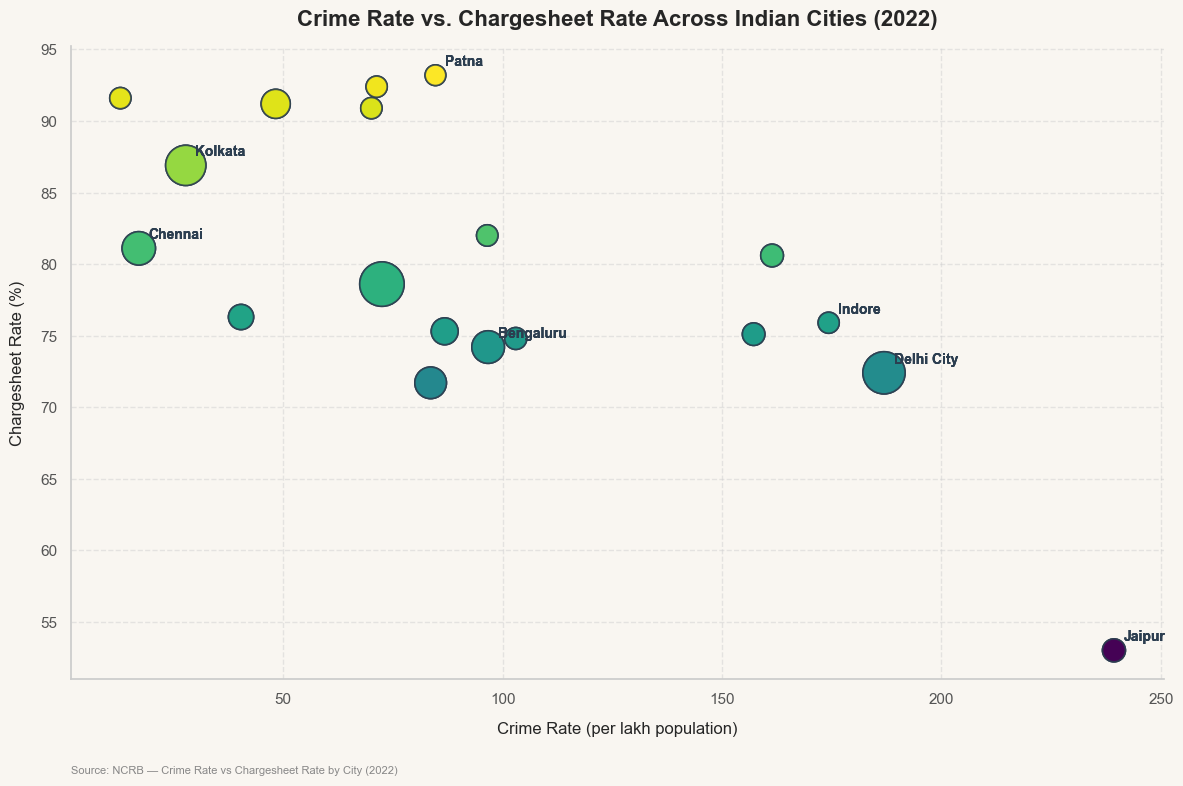

In [4]:
u.set_style()
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

latest_year = csv4["year"].max()
x = csv4["Rate of crime (%)"]
y = csv4["Chargesheet rate (%)"]
pop = csv4["Population as of 2011"]

sizes = (pop / pop.max()) * 900 + 120

scatter = ax.scatter(
    x,
    y,
    s=sizes,
    c=y,
    cmap="viridis",
    alpha=0.8,
    edgecolor="#2c3e50",
    linewidth=1.2,
)

for i, row in csv4.iterrows():
  city = row["Cities"]
  xi, yi = row["Rate of crime (%)"], row["Chargesheet rate (%)"]
  if city in [
      "Jaipur",
      "Indore",
      "Delhi City",
      "Patna",
      "Chennai",
      "Kolkata",
      "Bengaluru",
  ]:
    ax.annotate(
        city,
        xy=(xi, yi),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#2c3e50",
    )

ax.set_title(
    f"Crime Rate vs. Chargesheet Rate Across Indian Cities ({latest_year})",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Rate (per lakh population)", fontsize=12)
ax.set_ylabel("Chargesheet Rate (%)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(
    ax,
    f"NCRB — Crime Rate vs Chargesheet Rate by City ({latest_year})",
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_01_crime_vs_chargesheet_bubblechart.png")
plt.show()

Chart saved- charts/csv4_02_city_crime_grouped_bargraph.png


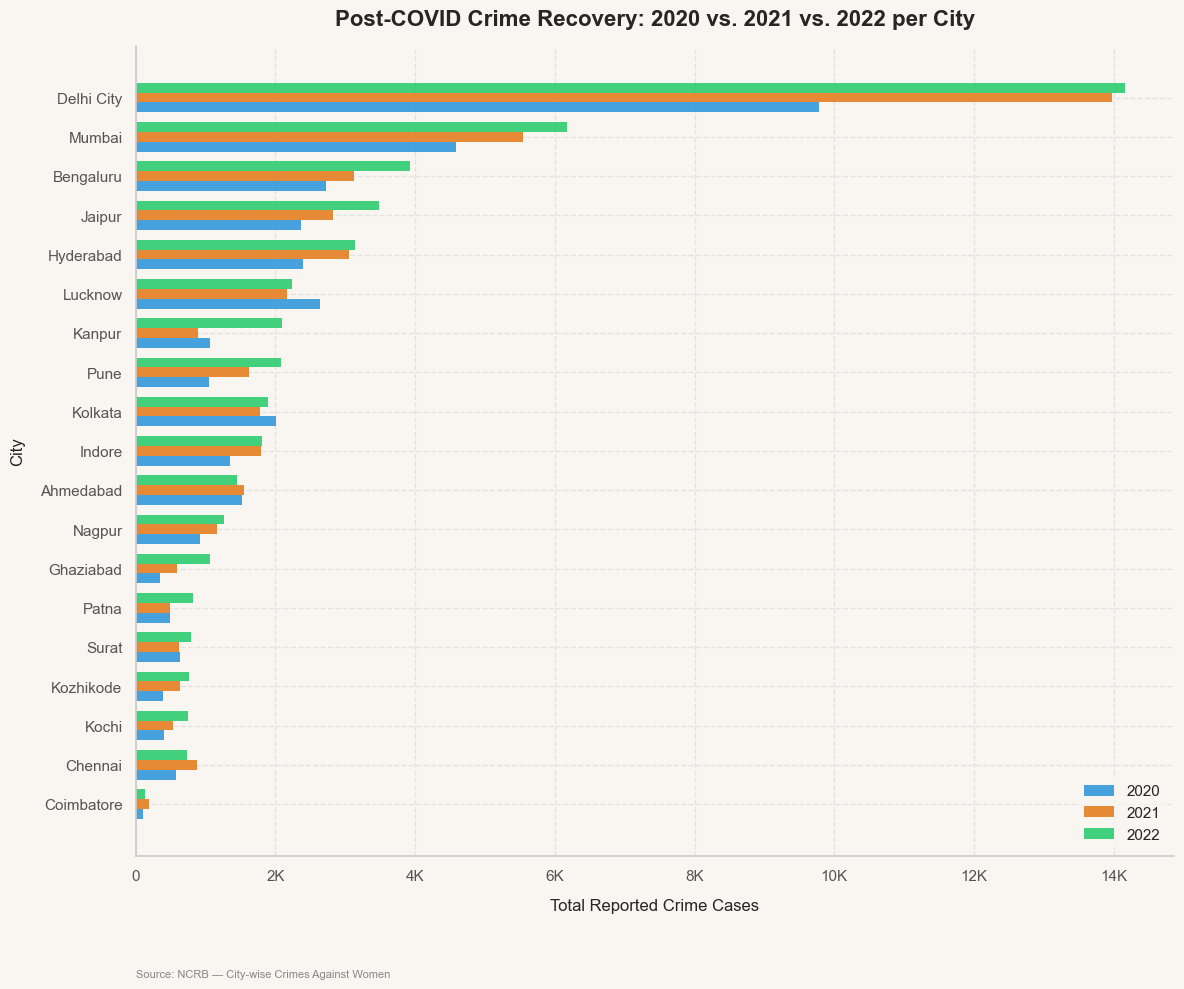

In [5]:
u.set_style()

pivot_df = csv4.pivot(
    index="Cities", columns="year", values="crime_cases"
).fillna(0)
pivot_df = pivot_df.sort_values(by=2022, ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = np.arange(len(pivot_df))
height = 0.25

ax.barh(
    y - height,
    pivot_df[2020],
    height,
    label="2020",
    color="#3498db",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y,
    pivot_df[2021],
    height,
    label="2021",
    color="#e67e22",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y + height,
    pivot_df[2022],
    height,
    label="2022",
    color="#2ecc71",
    edgecolor="none",
    alpha=0.9,
)

ax.set_yticks(y)
ax.set_yticklabels(pivot_df.index, fontsize=11)
ax.set_title(
    "Post-COVID Crime Recovery: 2020 vs. 2021 vs. 2022 per City",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Crime Cases", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)
ax.legend(
    frameon=True, facecolor=u.BG_COLOR, edgecolor="none", fontsize=11, loc="lower right"
)
ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(ax, "NCRB — City-wise Crimes Against Women")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_02_city_crime_grouped_bargraph.png")
plt.show()

Chart saved- charts/csv4_03_city_crime_rate_bargraph.png


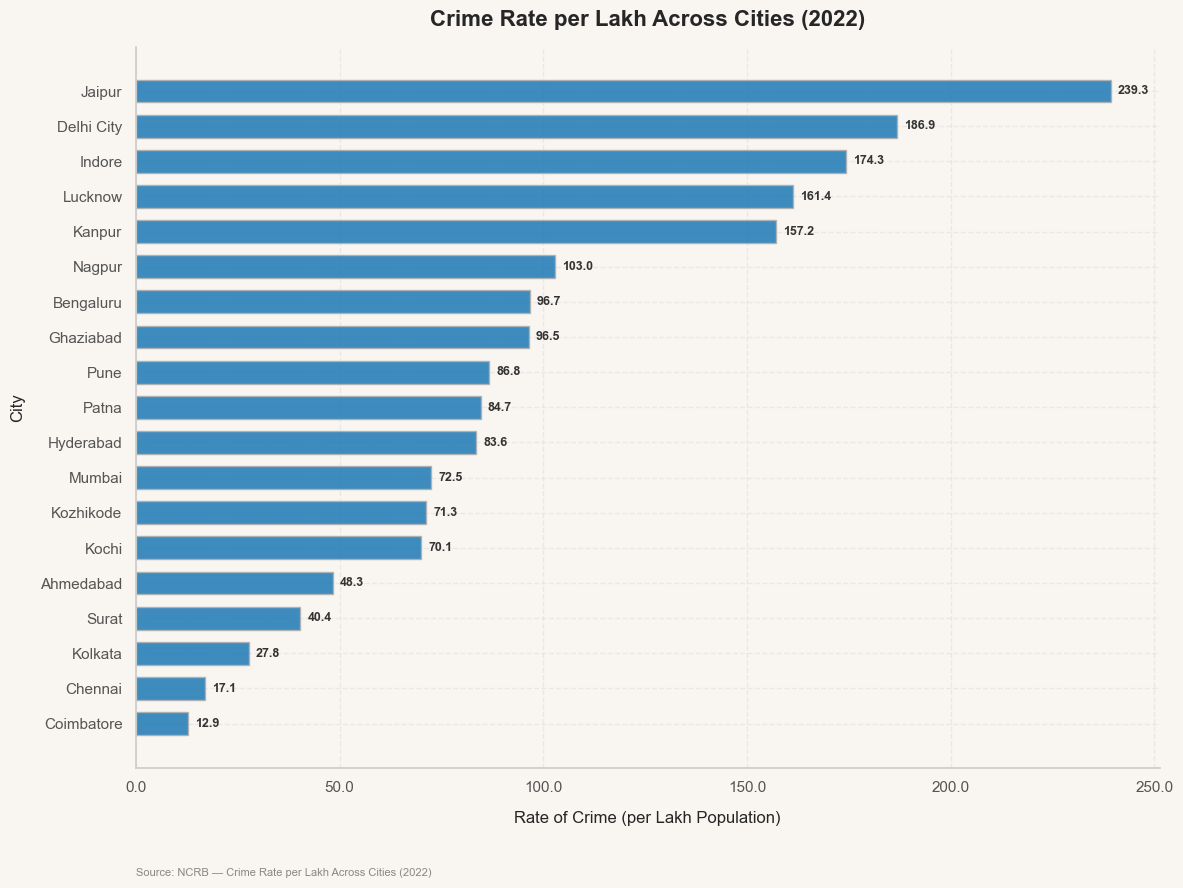

In [6]:
u.set_style()

csv4_2022 = csv4[csv4["year"] == 2022].copy()


# Sort by Rate of crime (%) ascending so lowest is at bottom, highest at top in barh
city_rates = csv4_2022.sort_values(by="Rate of crime (%)", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    city_rates["Cities"],
    city_rates["Rate of crime (%)"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crime Rate per Lakh Across Cities (2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Rate of Crime (per Lakh Population)", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.1f}"))

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:.1f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crime Rate per Lakh Across Cities (2022)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_03_city_crime_rate_bargraph.png")
plt.show()

## e. csv5 Analysis

Chart saved- charts/csv5_01_arrest_to_conviction_pipeline.png


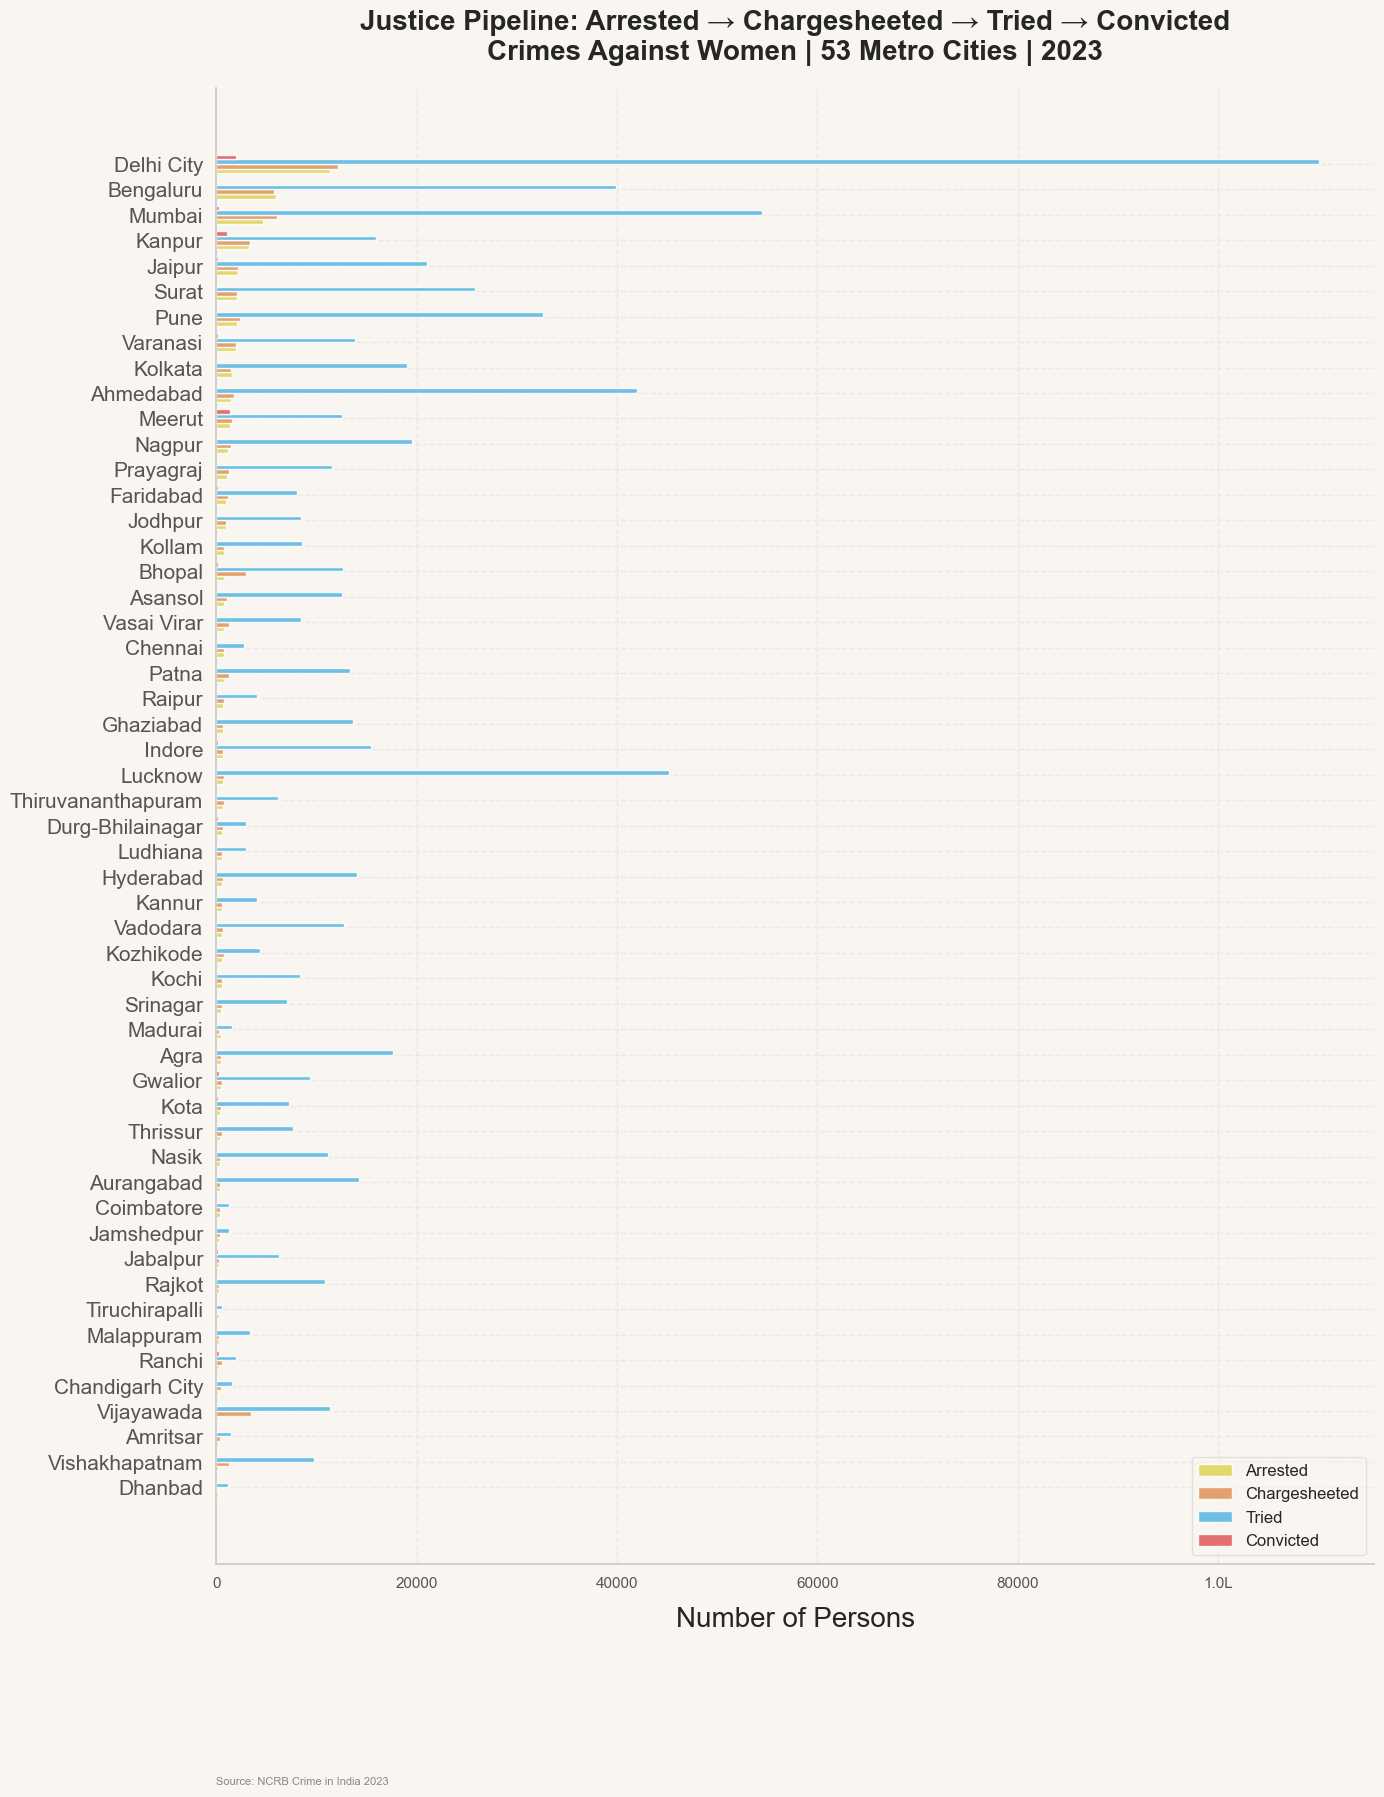

In [7]:
# Pipeline stages in logical order (both genders combined)
PIPELINE_STAGES = [
    "Persons Arrested in Cases Registered during the year",
    "Persons Arrested and Chargesheeted",
    "Persons in whose cases Trials were completed",
    "Persons Convicted",
]
STAGE_LABELS = ["Arrested", "Chargesheeted", "Tried", "Convicted"]
STAGE_COLORS = ["#e0d45c", "#e0955c", "#5cb8e0", "#e05c5c"]

# Aggregate both genders, keep only the 4 pipeline stages
pipe = (
    csv5[csv5["Crime"].isin(PIPELINE_STAGES)]
    .groupby(["city", "Crime"])["person_count"]
    .sum()
    .reset_index()
)
pipe["Stage"] = pipe["Crime"].map(dict(zip(PIPELINE_STAGES, STAGE_LABELS)))


pivot = (
    pipe.pivot(index="city", columns="Stage", values="person_count")
    [STAGE_LABELS]  
    .fillna(0)
    .sort_values("Arrested", ascending=True)   
)

u.set_style()
fig, ax = plt.subplots(figsize=(14, 18))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = range(len(pivot))
bar_h = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (stage, color) in enumerate(zip(STAGE_LABELS, STAGE_COLORS)):
    bars = ax.barh(
        [yi + offsets[i] * bar_h for yi in y],
        pivot[stage],
        height=bar_h,
        label=stage,
        color=color,
        alpha=0.88,
    )

ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index, fontsize=15)
ax.set_xlabel("Number of Persons", fontsize=20)
ax.set_title(
    "Justice Pipeline: Arrested → Chargesheeted → Tried → Convicted\nCrimes Against Women | 53 Metro Cities | 2023",
    fontsize=20, fontweight="bold", pad=20
)
ax.legend(loc="lower right", fontsize=12, framealpha=0.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))
u.add_source(ax, "NCRB Crime in India 2023")
plt.tight_layout()

u.save_fig(fig, "charts", "csv5_01_arrest_to_conviction_pipeline.png")
plt.show()

Chart saved- charts/csv5_02_gender_breakdown_arrests.png


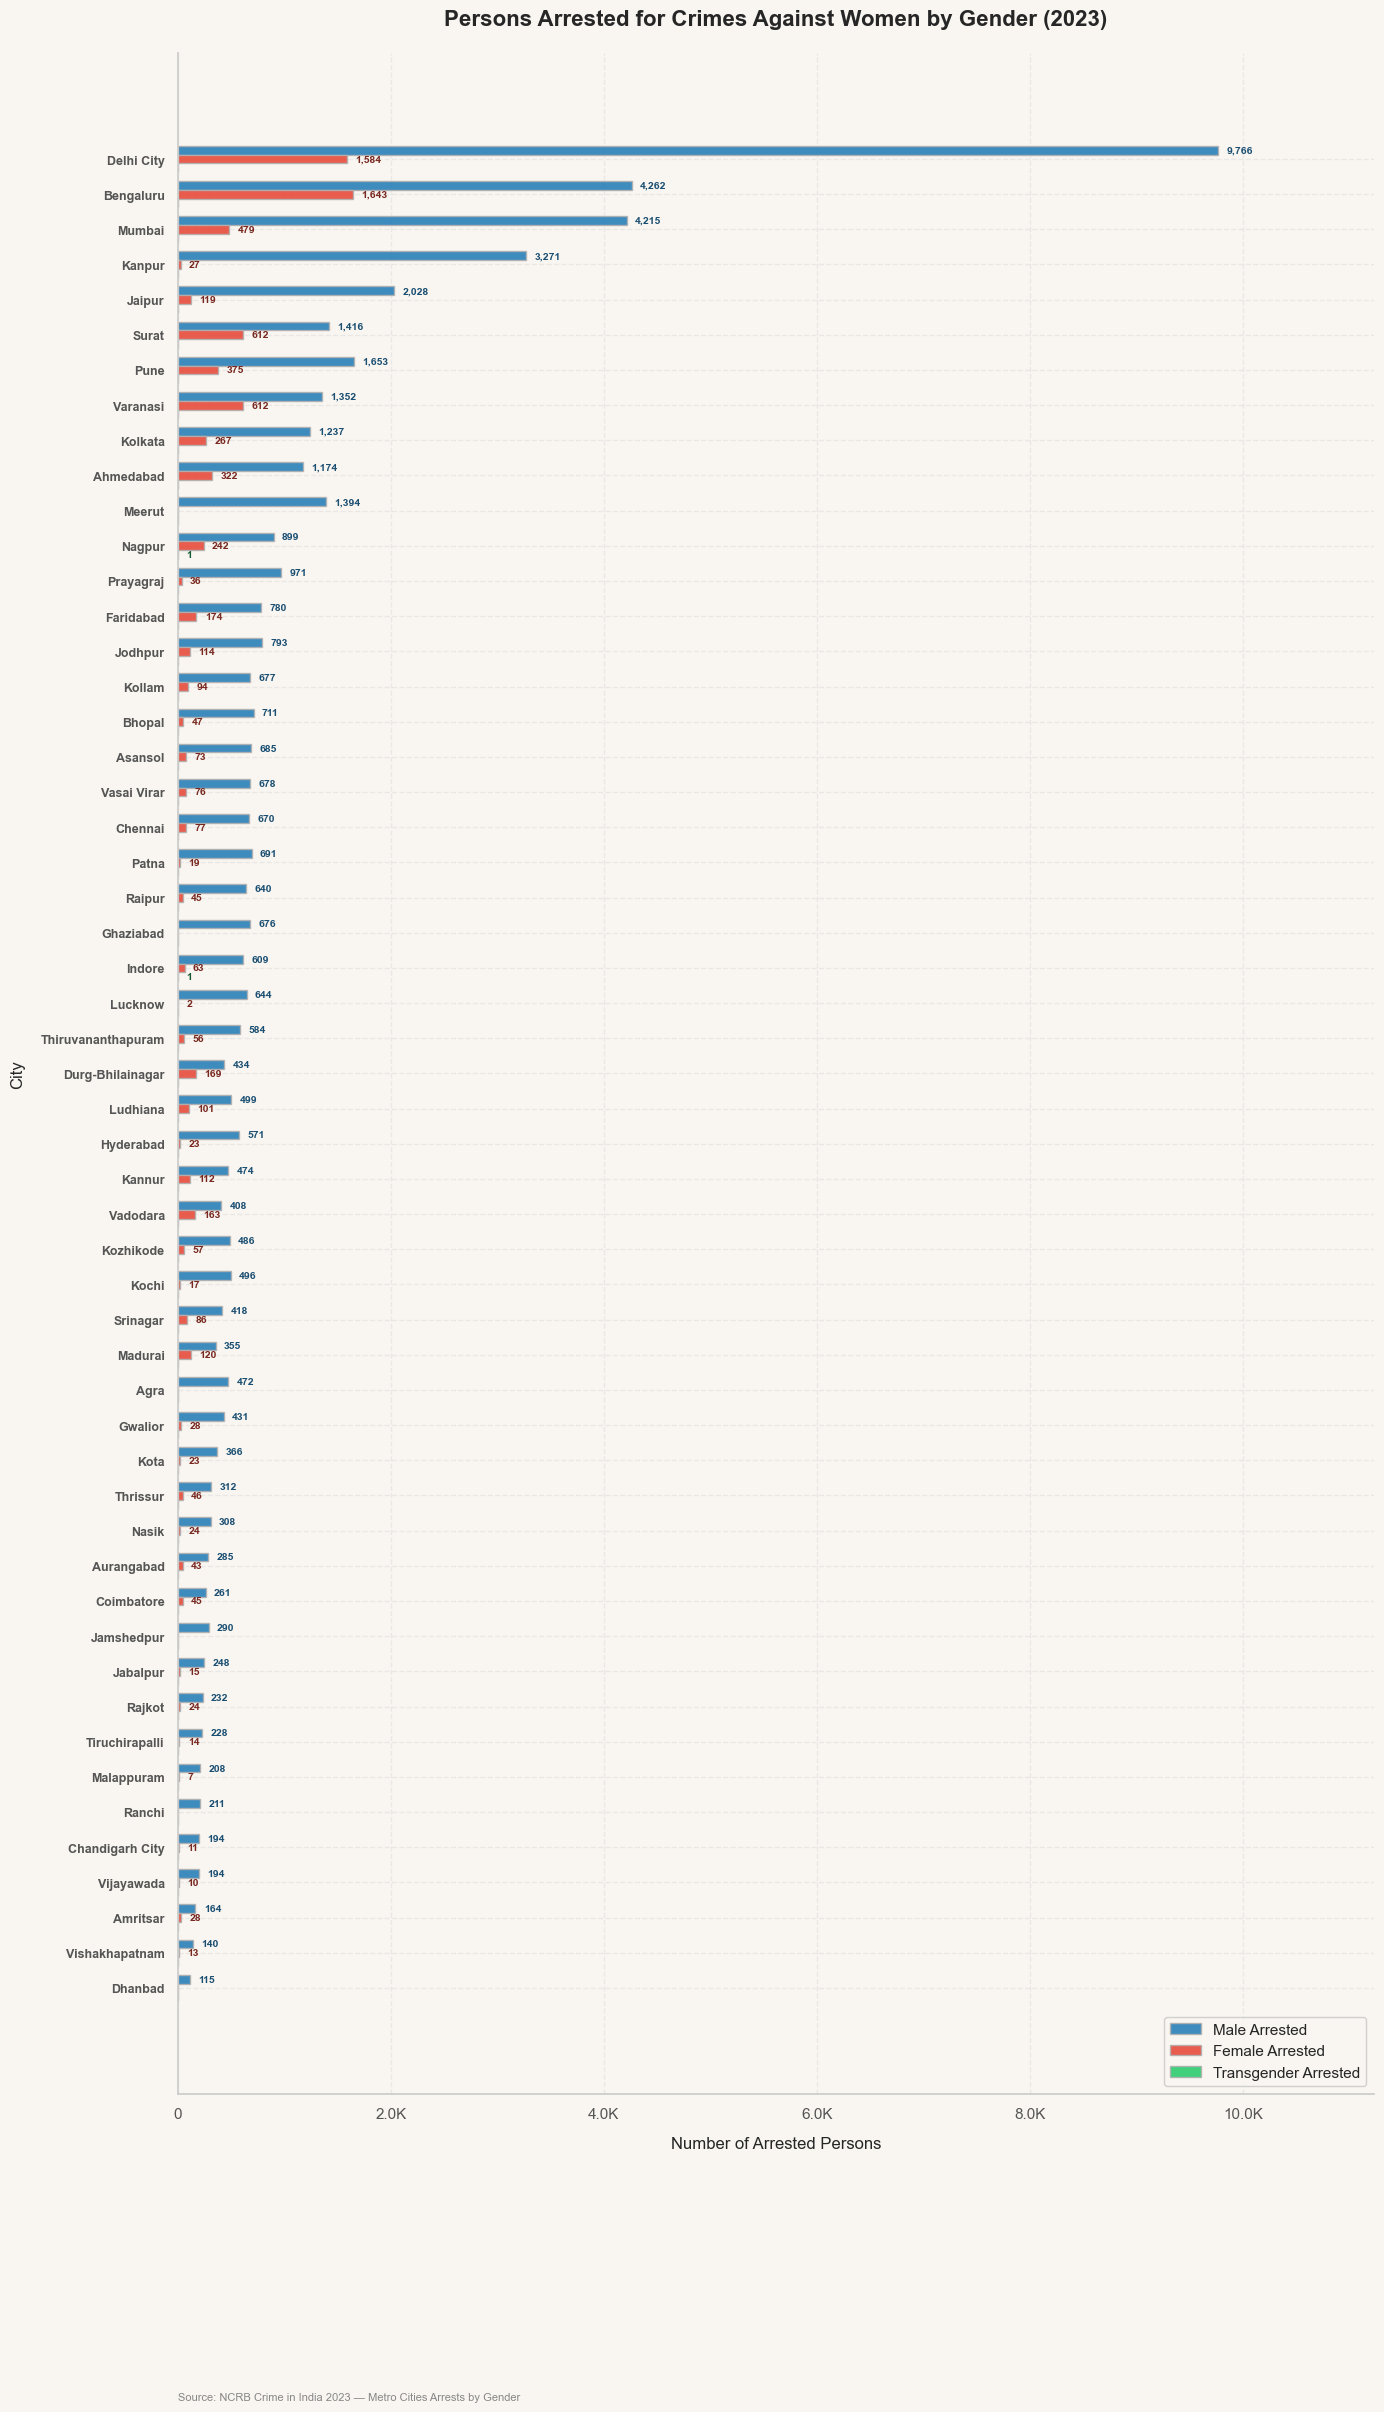

In [8]:
# Filter strictly for the "Arrested" stage
arrested_df = csv5[
    csv5["Crime"] == "Persons Arrested in Cases Registered during the year"
]

# Reshape / One-hot pivot across genders per city
pivot_df = arrested_df.pivot_table(
    index="city", columns="Arrested_Gender", values="person_count", aggfunc="sum"
).fillna(0)

# Ensure expected gender columns exist
for gender in ["Male", "Female", "Transgender"]:
    if gender not in pivot_df.columns:
        pivot_df[gender] = 0

# Calculate total arrests per city to sort cities
pivot_df["Total"] = (
    pivot_df["Male"] + pivot_df["Female"] + pivot_df["Transgender"]
)
top_cities = pivot_df.sort_values("Total", ascending=True)

u.set_style()

# Expanded figure height to space out all 53 cities vertically
fig, ax = plt.subplots(figsize=(14, 24))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = np.arange(len(top_cities))

# Reduced bar_height & assigned 3 distinct offsets (Male, Female, Transgender)
bar_height = 0.25
offsets = [bar_height, 0, -bar_height]

bars_m = ax.barh(
    y + offsets[0],
    top_cities["Male"],
    height=bar_height,
    label="Male Arrested",
    color="#2980b9",
    edgecolor="#b0b0b0",
    alpha=0.9,
)

bars_f = ax.barh(
    y + offsets[1],
    top_cities["Female"],
    height=bar_height,
    label="Female Arrested",
    color="#e74c3c",
    edgecolor="#b0b0b0",
    alpha=0.9,
)

bars_t = ax.barh(
    y + offsets[2],
    top_cities["Transgender"],
    height=bar_height,
    label="Transgender Arrested",
    color="#2ecc71",
    edgecolor="#b0b0b0",
    alpha=0.9,
)

# Axis configuration and styling
ax.set_yticks(y)
ax.set_yticklabels(top_cities.index, fontsize=9, fontweight="bold")
ax.set_title(
    "Persons Arrested for Crimes Against Women by Gender (2023)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Number of Arrested Persons", fontsize=12)
ax.set_ylabel("City", fontsize=12)

# Expand x-axis limit so annotations have padding on the right
max_val = top_cities["Male"].max()
ax.set_xlim(0, max_val * 1.15)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, pos: f"{x/1e3:.1f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

# Value annotations with offset points to prevent overlap with bars
for bar in bars_m:
    width = bar.get_width()
    if width > 0:
        ax.annotate(
            f"{width:,.0f}",
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color="#1b4f72",
        )

for bar in bars_f:
    width = bar.get_width()
    if width > 0:
        ax.annotate(
            f"{width:,.0f}",
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color="#78281f",
        )

for bar in bars_t:
    width = bar.get_width()
    if width > 0:
        ax.annotate(
            f"{width:,.0f}",
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color="#145a32",
        )

ax.legend(loc="lower right", fontsize=11, framealpha=0.9)
u.add_source(ax, "NCRB Crime in India 2023 — Metro Cities Arrests by Gender")

plt.tight_layout()
u.save_fig(fig, "charts", "csv5_02_gender_breakdown_arrests.png")
plt.show()

/var/folders/p_/8l92psx106q_nhcpkf5_sthw0000gn/T/ipykernel_57818/3152401866.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(sorted_ratios.index, fontsize=15, fontweight="bold")


Chart saved- charts/csv5_03_chargesheet_to_arrest_ratio_bar.png


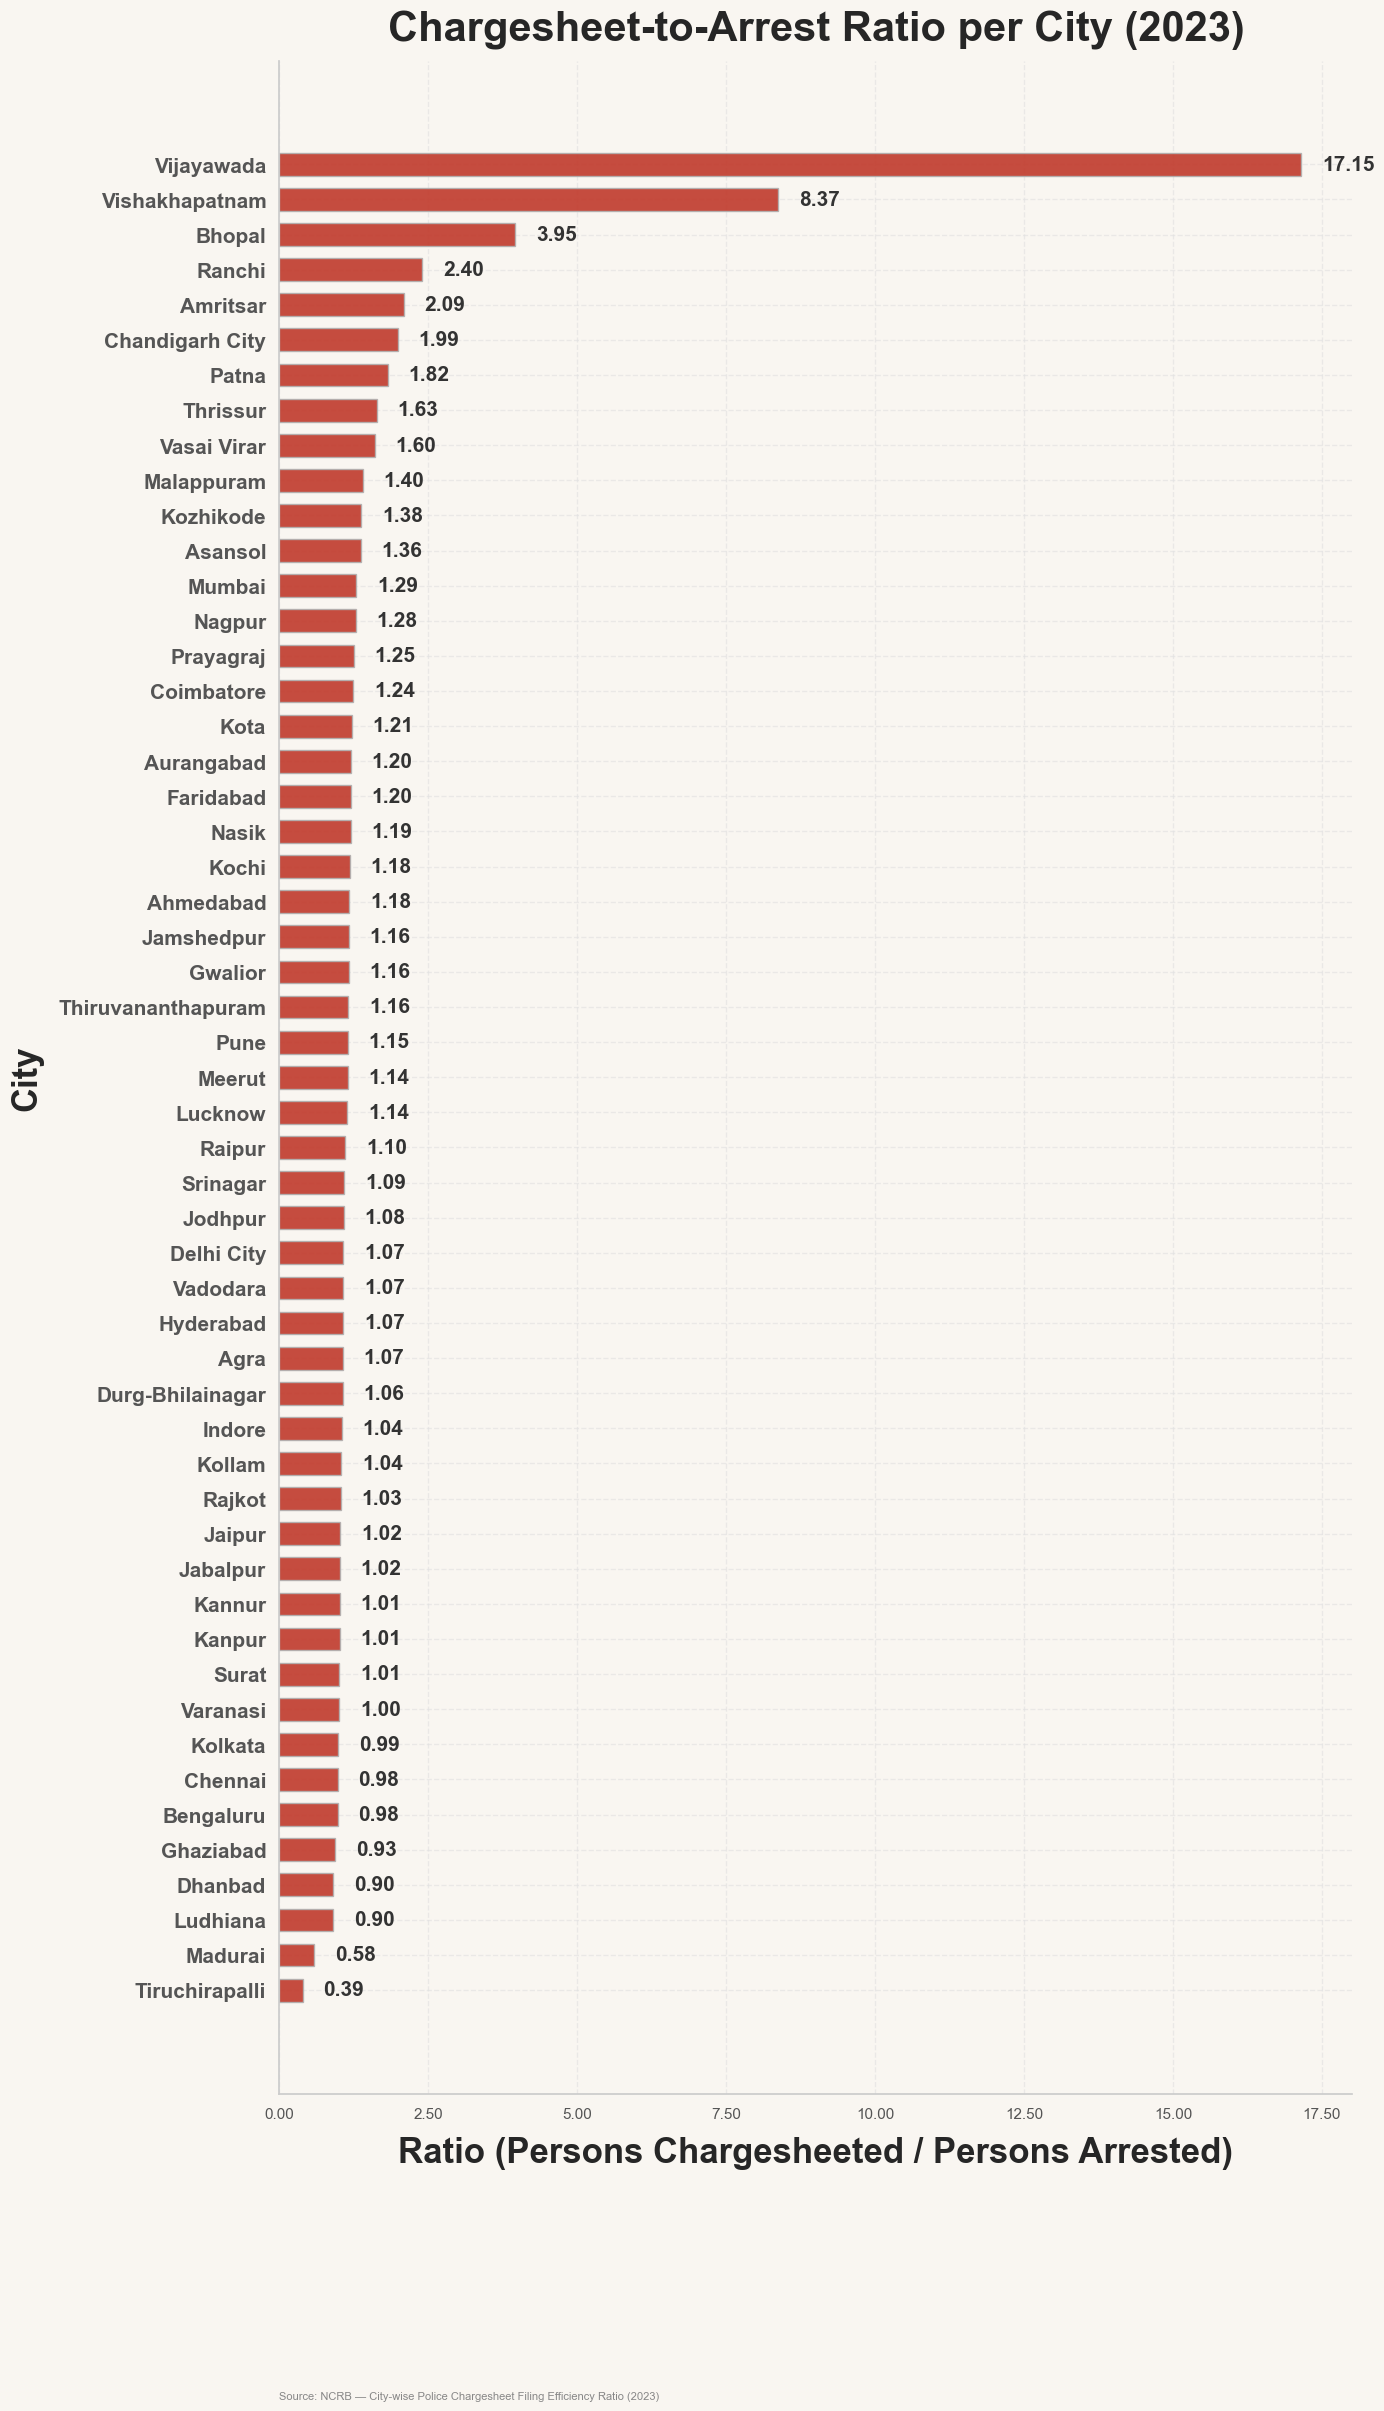

In [9]:
u.set_style()

# Clean column headers
csv5.columns = csv5.columns.str.strip()

# Separate persons arrested vs. persons chargesheeted entries
arrested_df = csv5[
    csv5["Crime"] == "Persons Arrested in Cases Registered during the year"
]

chargesheeted_df = csv5[
    csv5["Crime"] == "Persons Arrested and Chargesheeted"
]

# Aggregate person_count per city
arrested_totals = arrested_df.groupby("city")["person_count"].sum()
chargesheeted_totals = chargesheeted_df.groupby("city")["person_count"].sum()

# Construct derived ratio dataframe
ratio_df = pd.DataFrame({
    "Arrested": arrested_totals,
    "Chargesheeted": chargesheeted_totals
}).fillna(0)

# Filter out zero-arrest cities to prevent division by zero
ratio_df = ratio_df[ratio_df["Arrested"] > 0]
ratio_df["Ratio"] = ratio_df["Chargesheeted"] / ratio_df["Arrested"]

# Sort ascending so cities with lowest filing ratios appear prominently
sorted_ratios = ratio_df["Ratio"].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 24))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = np.arange(len(top_cities))

bar_height = 0.15
offsets = [bar_height, 0, -bar_height]

bars = ax.barh(
    sorted_ratios.index,
    sorted_ratios.values,
    color="#c0392b",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Chargesheet-to-Arrest Ratio per City (2023)",
    fontsize=30,
    fontweight="bold",
)

ax.set_xlabel("Ratio (Persons Chargesheeted / Persons Arrested)", fontsize=25, fontweight="bold")
ax.set_ylabel("City", fontsize=25, fontweight="bold")
ax.set_yticklabels(sorted_ratios.index, fontsize=15, fontweight="bold")

# Format x-axis ticks to two decimal places
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:.2f}")
)

# Annotate each bar with the exact ratio value
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:.2f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(15, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — City-wise Police Chargesheet Filing Efficiency Ratio (2023)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv5_03_chargesheet_to_arrest_ratio_bar.png")
plt.show()

Chart saved- charts/csv5_04_conviction_rate_by_city.png


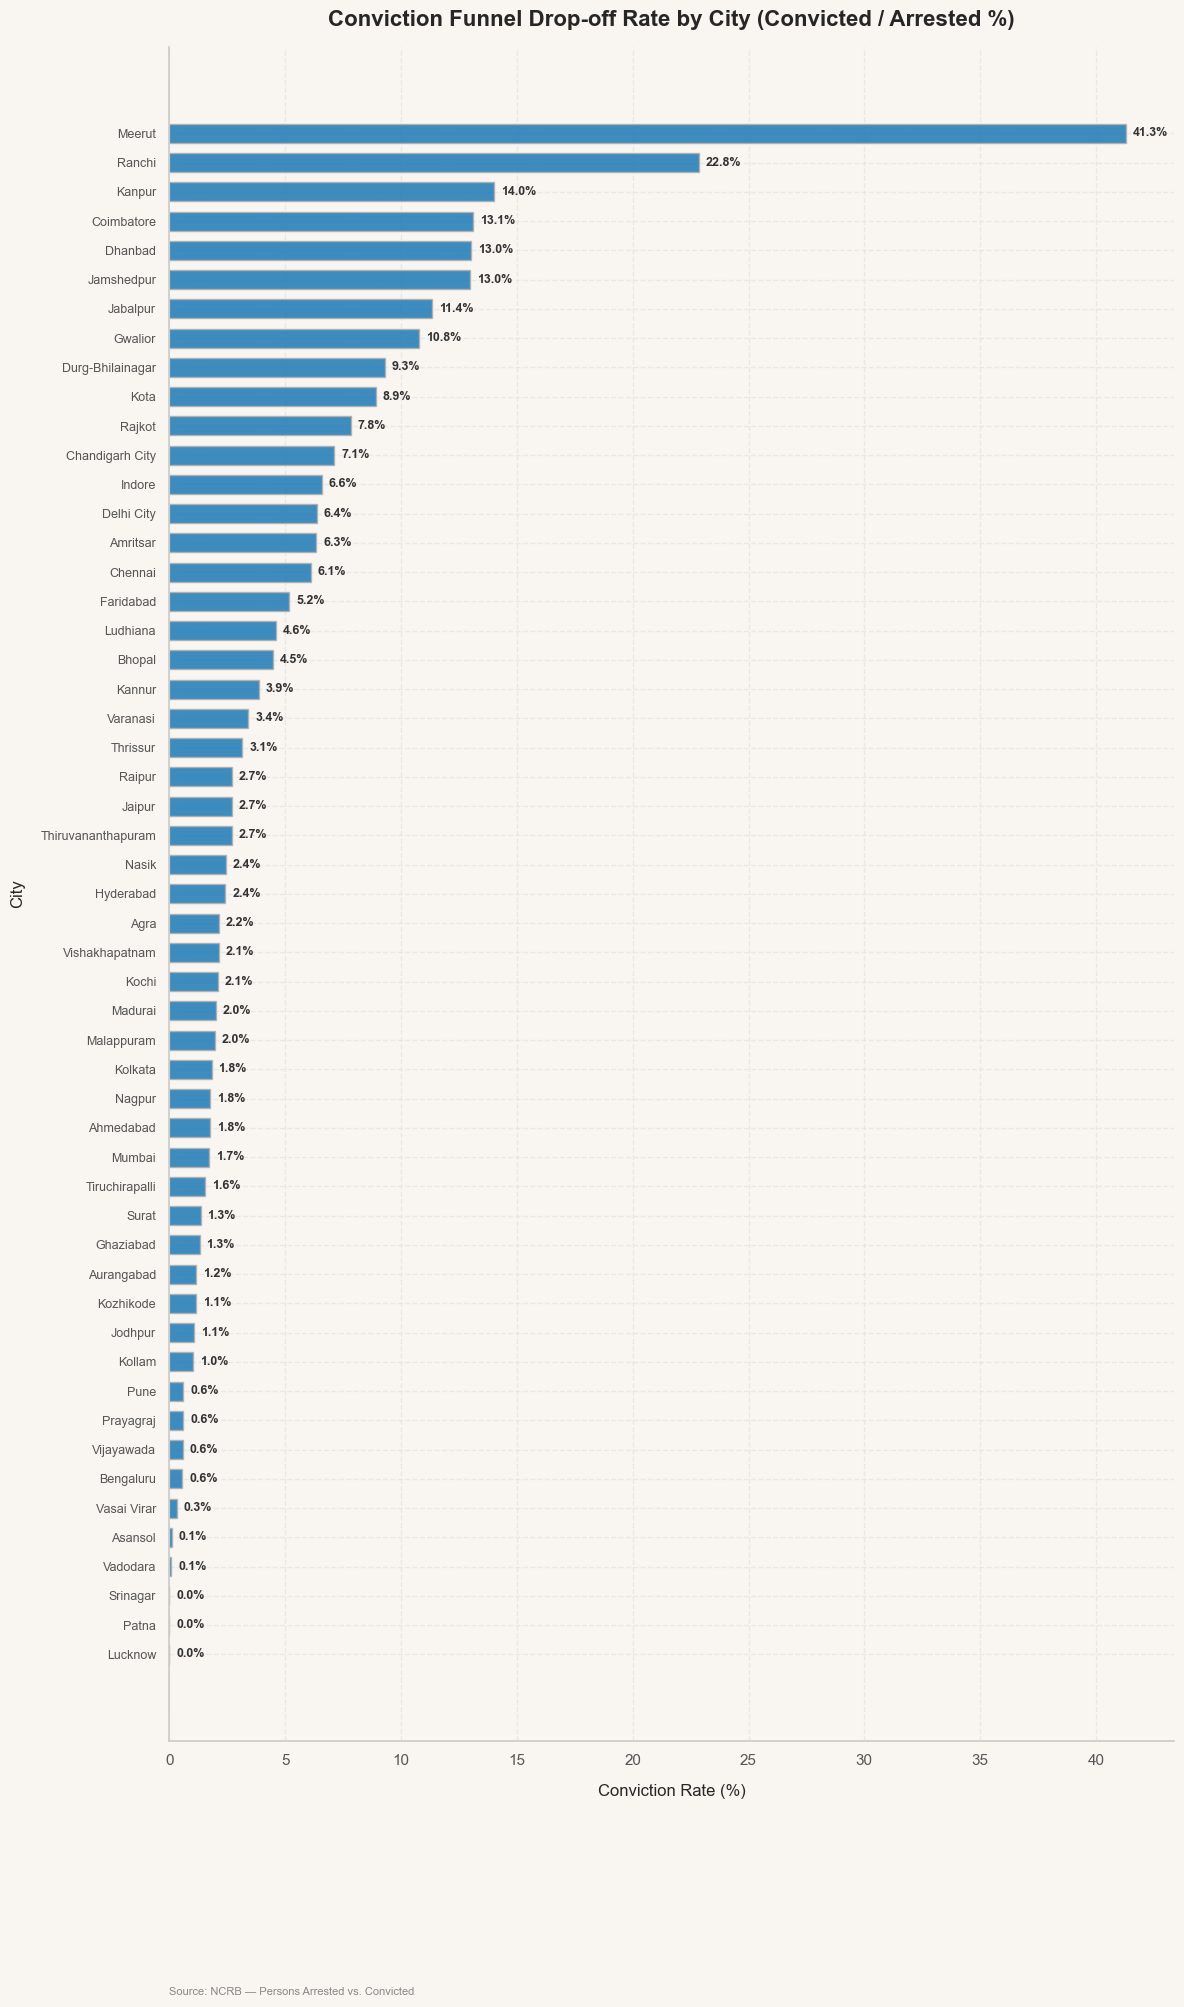

In [10]:
u.set_style()

csv5.columns = csv5.columns.str.strip()

# Process 'Arrested_Gender' to categorize stage into Arrested vs. Convicted
def categorize_stage(text):
    text_lower = str(text).lower()
    if "convict" in text_lower:
        return "Convicted"
    elif "arrest" in text_lower:
        return "Arrested"
    return "Other"

csv5["Stage"] = csv5['Crime'].apply(categorize_stage)

# Pivot data to sum counts by City and Stage
city_totals = csv5.groupby(["city", "Stage"])["person_count"].sum().unstack(fill_value=0)


if "Arrested" in city_totals.columns and "Convicted" in city_totals.columns:
    # 4. Calculate Conviction Rate (%) = (Convicted / Arrested) * 100
    city_totals["Conviction_Rate"] = (
        city_totals["Convicted"] / city_totals["Arrested"]
    ) * 100
    city_totals["Conviction_Rate"] = (
        city_totals["Conviction_Rate"].replace([float("inf"), -float("inf")], 0).fillna(0)
    )
else:
    raise ValueError("Could not locate 'Arrested' and 'Convicted' stages in Arrested_Gender.")

# Sort cities ascending for horizontal bar chart display
sorted_cities = city_totals.sort_values("Conviction_Rate", ascending=True)

fig, ax = plt.subplots(figsize=(12, 20))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    sorted_cities.index,
    sorted_cities["Conviction_Rate"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Conviction Funnel Drop-off Rate by City (Convicted / Arrested %)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Conviction Rate (%)", fontsize=12)
ax.set_ylabel("City", fontsize=12)
ax.tick_params(axis="y", labelsize=9)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Persons Arrested vs. Convicted")

plt.tight_layout()
u.save_fig(fig, "charts", "csv5_04_conviction_rate_by_city.png")
plt.show()

## f. csv6 Analysis

Chart saved- charts/csv6_01_total_cases_by_city.png


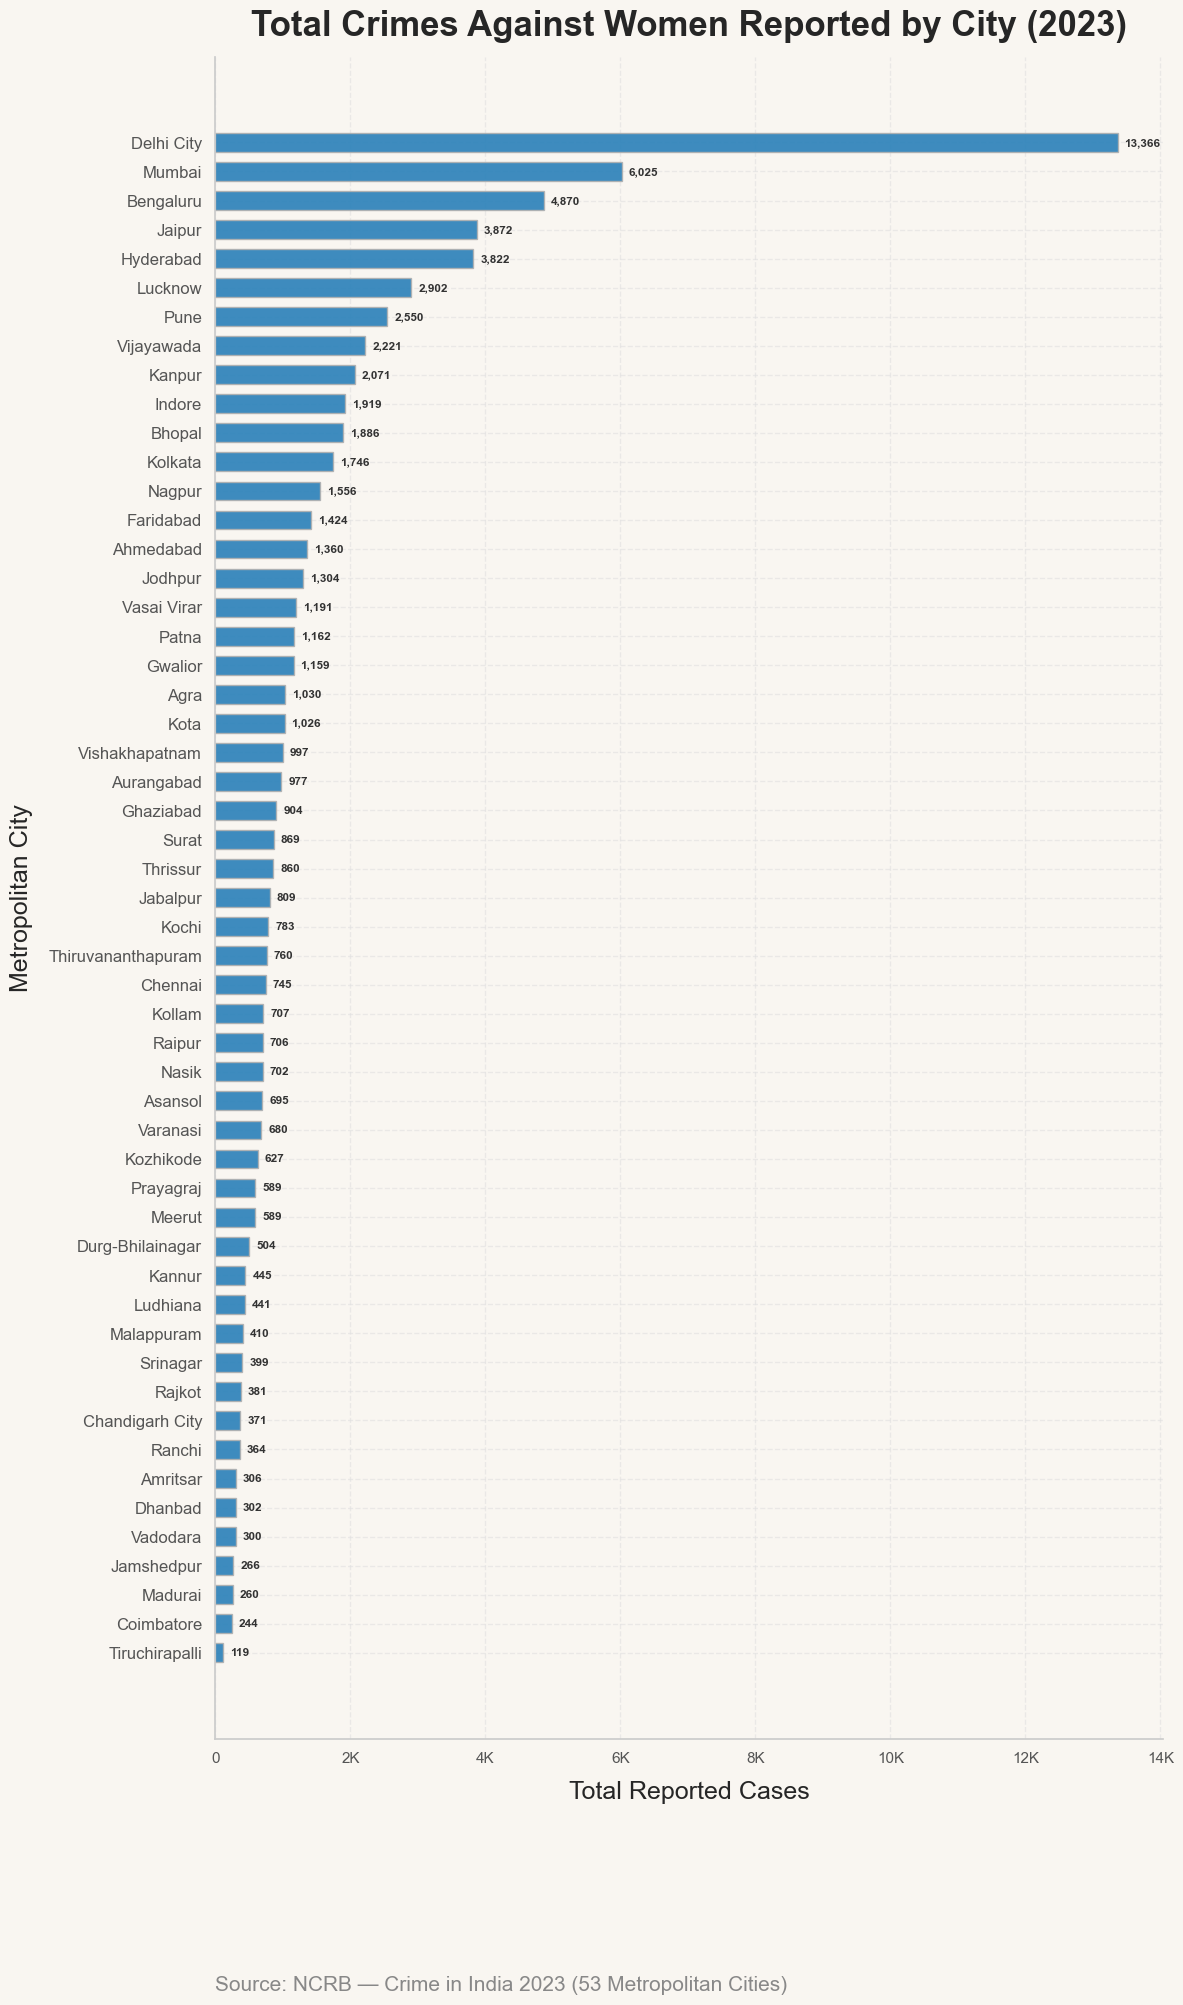

In [11]:
u.set_style()

csv6.columns = csv6.columns.str.strip()

# Convert total cases to numeric and sort ascending for horizontal ranking display
csv6['Cases Reported during the year 2023'] = pd.to_numeric(csv6["Cases Reported during the year 2023"], errors="coerce").fillna(0)
sorted_cities = csv6.sort_values("Cases Reported during the year 2023", ascending=True)

# Figure setup with height spaced out for all 53 metropolitan cities
fig, ax = plt.subplots(figsize=(12, 20))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    sorted_cities["53 Metropolitan Cities"],
    sorted_cities["Cases Reported during the year 2023"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Crimes Against Women Reported by City (2023)",
    fontsize=25,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Cases", fontsize=18)
ax.set_ylabel("Metropolitan City", fontsize=18)
ax.tick_params(axis="y", labelsize=12)

# Format X-axis tick values in thousands (K)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}")
)

# Annotate exact case count on each bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Crime in India 2023 (53 Metropolitan Cities)", 15)

plt.tight_layout()
u.save_fig(fig, "charts", "csv6_01_total_cases_by_city.png")
plt.show()

Chart saved- charts/csv6_02_pct_156_3_by_city.png


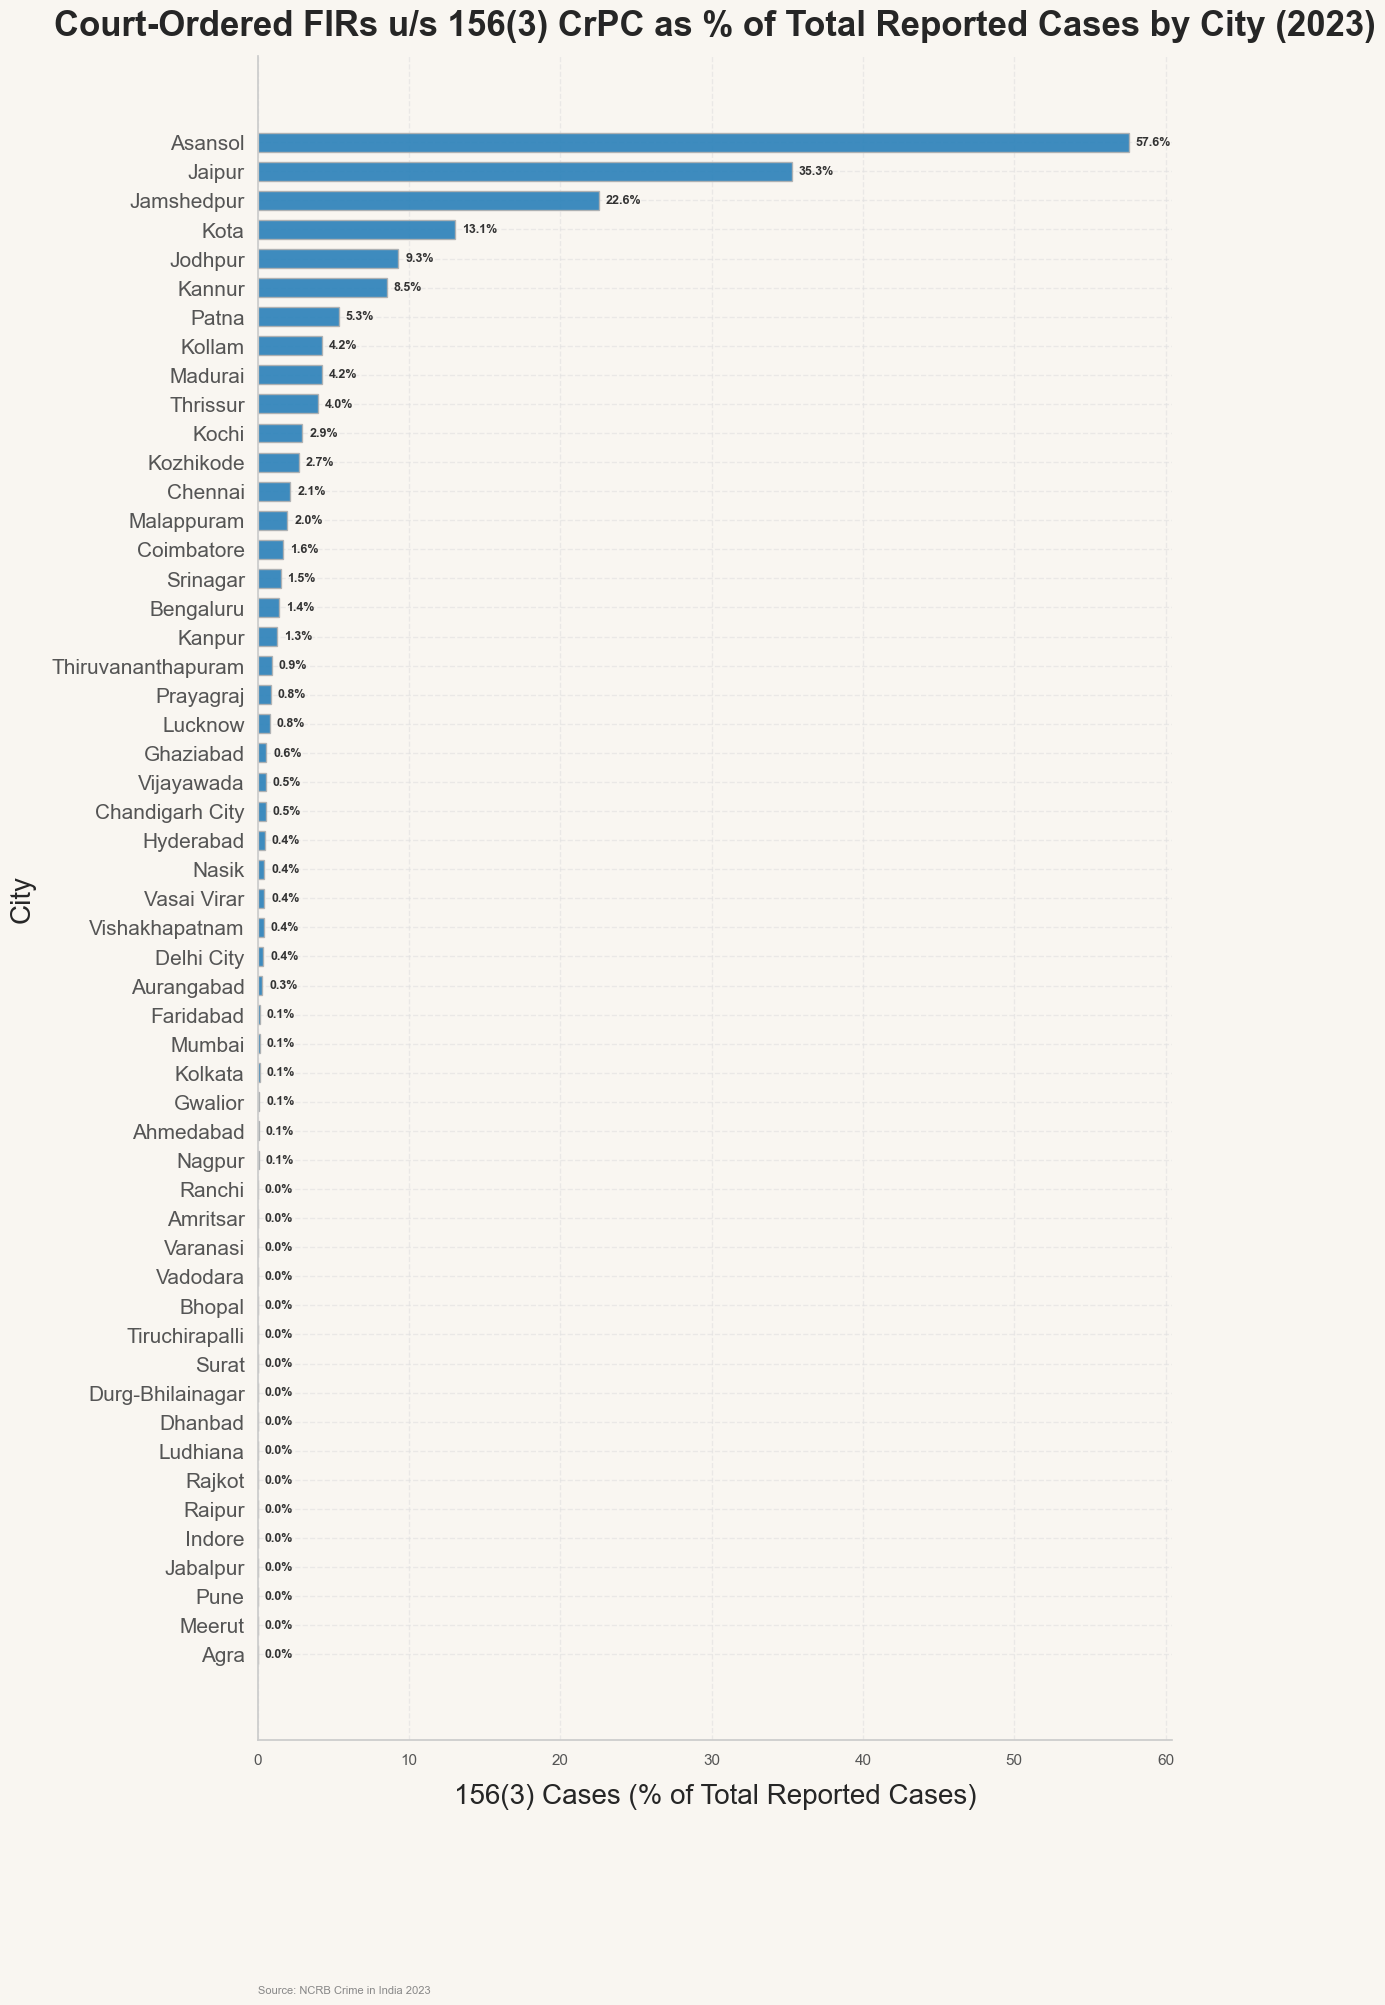

In [12]:
u.set_style()

csv6.columns = csv6.columns.str.strip()

# Calculate % of 156(3) court-ordered cases out of total reported cases
csv6["pct_156_3"] = (
    csv6["Cases Reported Under 156_3 during the year 2023"]
    / csv6["Cases Reported during the year 2023"]
) * 100
csv6["pct_156_3"] = (
    csv6["pct_156_3"].replace([float("inf"), -float("inf")], 0).fillna(0)
)

# Sort ascending so top percentage cities appear at the top in horizontal barplot
sorted_cities = csv6.sort_values("pct_156_3", ascending=True)

# Initialize tall figure to space out all 53 cities cleanly
fig, ax = plt.subplots(figsize=(12, 20))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    sorted_cities["53 Metropolitan Cities"],
    sorted_cities["pct_156_3"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Court-Ordered FIRs u/s 156(3) CrPC as % of Total Reported Cases by City (2023)",
    fontsize=25,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("156(3) Cases (% of Total Reported Cases)", fontsize=20)
ax.set_ylabel("City", fontsize=20)
ax.tick_params(axis="y", labelsize=15)

# Annotate values on each bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB Crime in India 2023")

plt.tight_layout()
u.save_fig(fig, "charts", "csv6_02_pct_156_3_by_city.png")
plt.show()

Chart saved- charts/csv4_csv6_chargesheet_vs_156_3.png


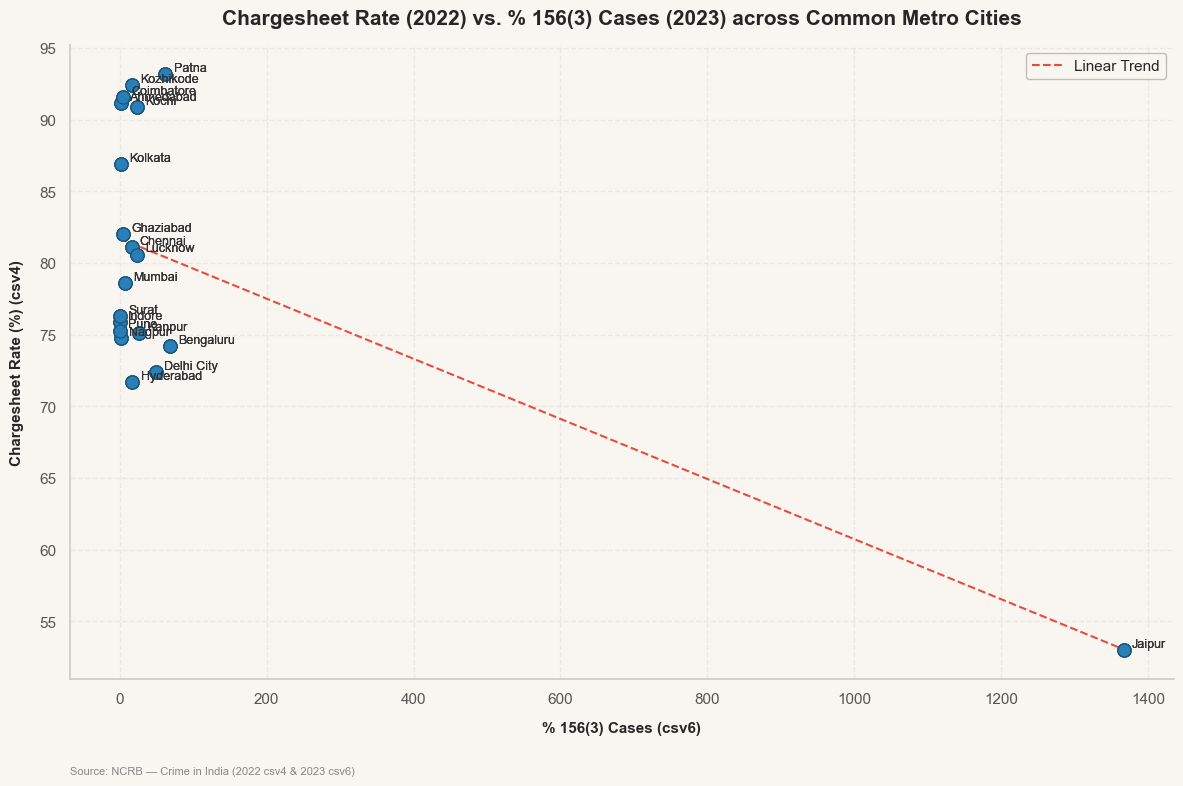

In [13]:
u.set_style()

# Clean column headers
csv4.columns = csv4.columns.str.strip()
csv6.columns = csv6.columns.str.strip()

csv6['53 Metropolitan Cities']
# Standardize city names for accurate matching
csv4["city_clean"] = csv4["Cities"].astype(str).str.strip().str.title()
csv6["city_clean"] = csv6["53 Metropolitan Cities"].astype(str).str.strip().str.title()

# Identify target column names dynamically across both CSVs
chargesheet_col = [
    col for col in csv4.columns if "chargesheet" in col.lower()
][0]
pct_156_col = [
    col for col in csv6.columns if "156(3)" in col or "156_3" in col.lower()
][0]

# Merge on common cities present in both datasets
merged_df = pd.merge(
    csv4,
    csv6,
    on="city_clean",
    suffixes=("_csv4", "_csv6"),
    how="inner",
)

# Convert numeric metrics to float
merged_df[chargesheet_col] = pd.to_numeric(
    merged_df[chargesheet_col], errors="coerce"
)
merged_df[pct_156_col] = pd.to_numeric(
    merged_df[pct_156_col], errors="coerce"
)

# Drop missing records
plot_data = merged_df.dropna(subset=[chargesheet_col, pct_156_col])

# Create Scatter Plot
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Plot city data points
ax.scatter(
    plot_data[pct_156_col],
    plot_data[chargesheet_col],
    color="#2980b9",
    s=90,
    edgecolor="#1a5276",
    alpha=0.85,
    zorder=3,
)

# Annotate city labels for each scatter point
for _, row in plot_data.iterrows():
    ax.annotate(
        row["city_clean"],
        xy=(row[pct_156_col], row[chargesheet_col]),
        xytext=(6, 2),
        textcoords="offset points",
        fontsize=9,
        color="#333333",
        alpha=0.9,
    )

# Fit optional trendline to assess hypothesis correlation
if len(plot_data) > 1:
    x = plot_data[pct_156_col]
    y = plot_data[chargesheet_col]
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        x_line,
        slope * x_line + intercept,
        color="#e74c3c",
        linestyle="--",
        linewidth=1.5,
        label="Linear Trend",
        zorder=2,
    )
    ax.legend(frameon=True, facecolor=u.BG_COLOR, edgecolor="#b0b0b0")

# Titles and Axis Labels
ax.set_title(
    "Chargesheet Rate (2022) vs. % 156(3) Cases (2023) across Common Metro Cities",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("% 156(3) Cases (csv6)", fontsize=11, fontweight="bold")
ax.set_ylabel(
    "Chargesheet Rate (%) (csv4)", fontsize=11, fontweight="bold"
)

# Add source and save
u.add_source(ax, "NCRB — Crime in India (2022 csv4 & 2023 csv6)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_csv6_chargesheet_vs_156_3.png")
plt.show()

## g. csv7 Analysis

In [14]:
csv7.columns

Index(['Category', 'State/UT', 'Offense_Category', 'Offense_Subcategory',
       'Incidents'],
      dtype='object')

In [15]:
csv7['State/UT'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Andaman & Nicobar Islands',
       'Chandigarh', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi',
       'Lakshadweep', 'Puducherry'], dtype=object)

Chart saved- charts/csv7_01_state_rape_cases_bar.png


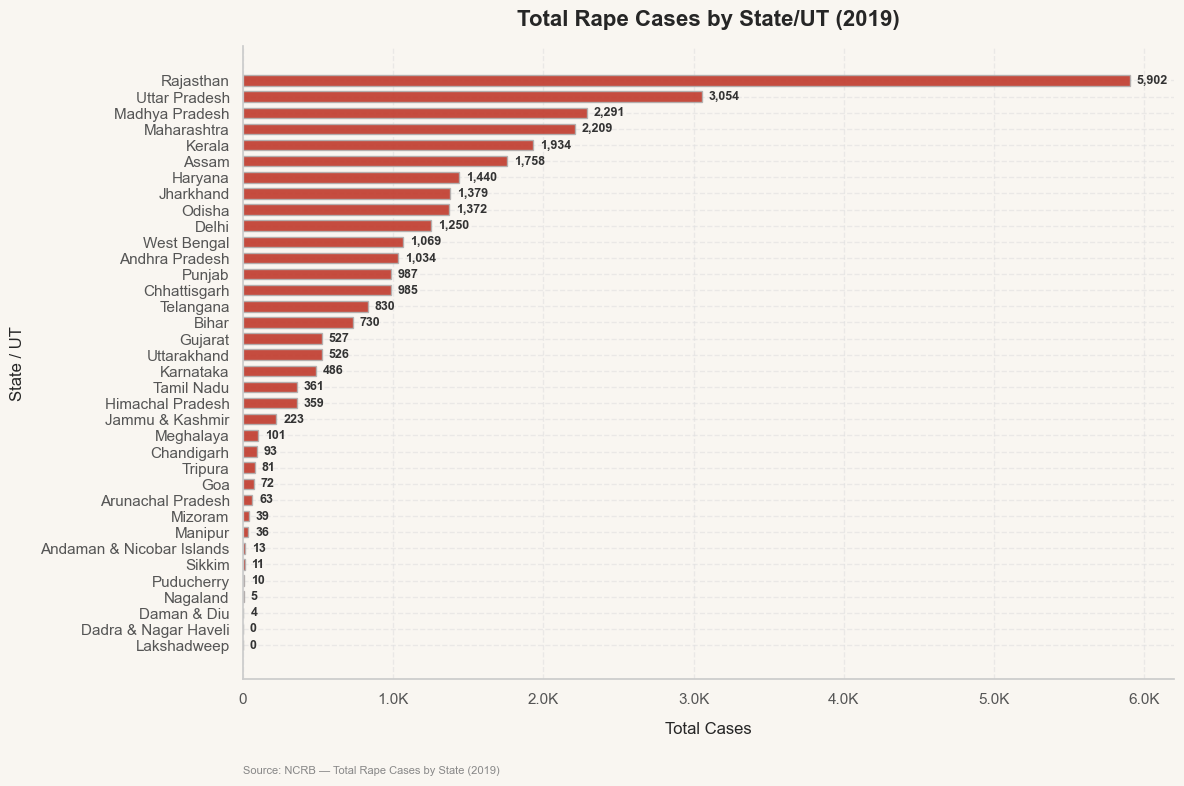

In [16]:
u.set_style()

# Group by State/UT to get total rape cases and sort for the horizontal bar
state_totals = (
    csv7.groupby("State/UT")["Incidents"]
    .sum()
    .sort_values(ascending=True)
)


fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Using a stark red to emphasize the severity of the data
bars = ax.barh(
    state_totals.index,
    state_totals.values,
    color="#c0392b",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Rape Cases by State/UT (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1e3:.1f}K" if x >= 1e3 else f"{x:.0f}")
)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Total Rape Cases by State (2019)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_01_state_rape_cases_bar.png")
plt.show()

Chart saved- charts/csv7_02_rape_type_composition_by_state.png


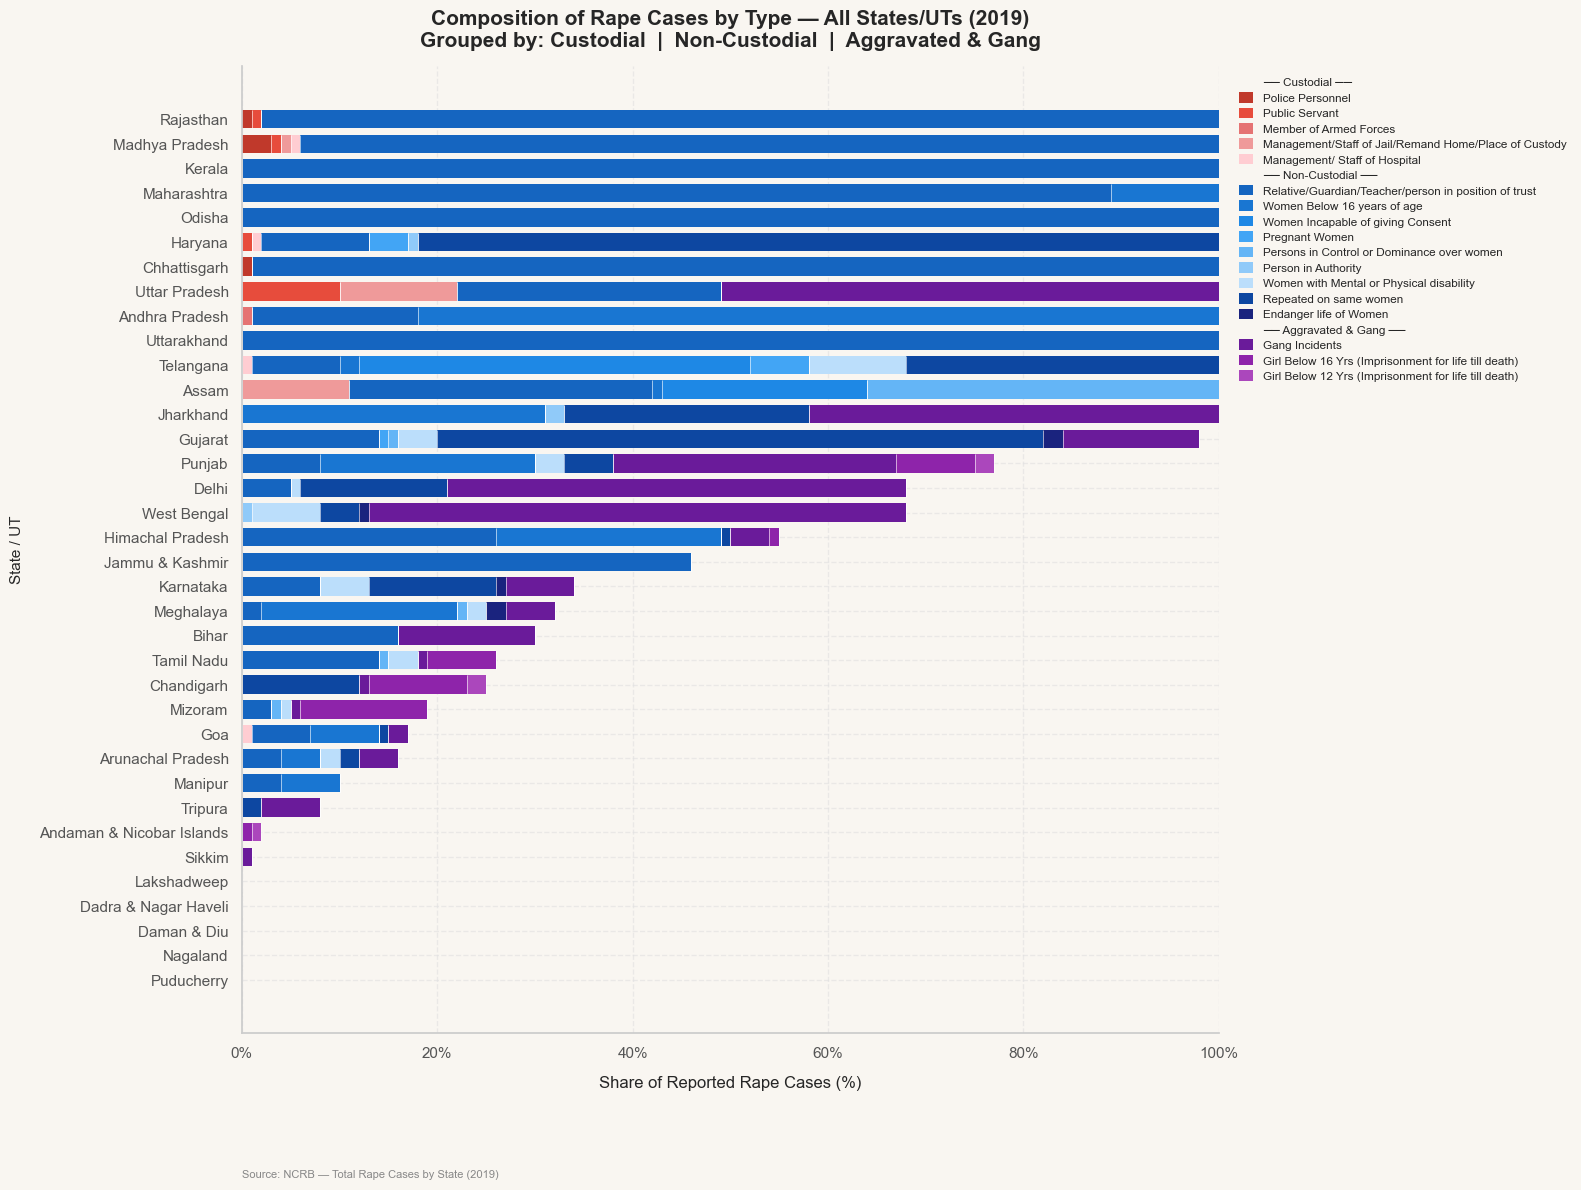

In [17]:
u.set_style()

# 1. Exclude "Penalties & Legal Provisions" as those are sentencing labels,
# not offense types; including them would misrepresent totals
offense_df = csv7[~csv7["Offense_Category"].isin(["Penalties & Legal Provisions"])].copy()

# 2. Collapse to State × Subcategory totals
pivot = (
    offense_df
    .groupby(["State/UT", "Offense_Subcategory"])["Incidents"]
    .sum()
    .unstack(fill_value=0)
)

pivot["_total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("_total", ascending=True).drop(columns="_total")

COL_ORDER = [
    # Custodial
    "Police Personnel",
    "Public Servant",
    "Member of Armed Forces",
    "Management/Staff of Jail/Remand Home/Place of Custody",
    "Management/ Staff of Hospital",
    # Non-Custodial
    "Relative/Guardian/Teacher/person in position of trust",
    "Women Below 16 years of age",
    "Women Incapable of giving Consent",
    "Pregnant Women",
    "Persons in Control or Dominance over women",
    "Person in Authority",
    "Women with Mental or Physical disability",
    "Repeated on same women",
    "Endanger life of Women",
    # Aggravated & Gang
    "Gang Incidents",
    "Girl Below 16 Yrs (Imprisonment for life till death)",
    "Girl Below 12 Yrs (Imprisonment for life till death)",
]
# only keep cols that exist in data
COL_ORDER = [c for c in COL_ORDER if c in pivot.columns]
pivot = pivot[COL_ORDER]

#        Custodial = reds (5), Non-Custodial = blues (9), Aggravated = purples (3)
COLORS = [
    # Custodial
    "#c0392b", "#e74c3c", "#e57373", "#ef9a9a", "#ffcdd2",
    # Non-Custodial
    "#1565c0", "#1976d2", "#1e88e5", "#42a5f5", "#64b5f6",
    "#90caf9", "#bbdefb", "#0d47a1", "#1a237e",
    # Aggravated & Gang
    "#6a1b9a", "#8e24aa", "#ab47bc",
]


fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

lefts = np.zeros(len(pivot))
bars_handles = []
for col, color in zip(COL_ORDER, COLORS):
    vals = pivot[col].values
    bar = ax.barh(
        pivot.index,
        vals,
        left=lefts,
        color=color,
        edgecolor="none",
        height=0.75,
        label=col,
    )
    bars_handles.append(bar)
    lefts += vals

    # thin boundary at the right edge of each segment
    ax.vlines(
        x=lefts,
        ymin=np.arange(len(pivot)) - 0.375,
        ymax=np.arange(len(pivot)) + 0.375,
        colors="white",
        linewidth=0.6,
        alpha=0.7,
    )

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of Reported Rape Cases (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=11)
ax.set_title(
    "Composition of Rape Cases by Type — All States/UTs (2019)\n"
    "Grouped by: Custodial  |  Non-Custodial  |  Aggravated & Gang",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

from matplotlib.lines import Line2D
divider = Line2D([0], [0], color="none")  # invisible spacer

legend_handles = []
legend_labels  = []

sections = {
    "── Custodial ──": slice(0, 5),
    "── Non-Custodial ──": slice(5, 14),
    "── Aggravated & Gang ──": slice(14, 17),
}
for section_label, slc in sections.items():
    legend_handles.append(divider)
    legend_labels.append(section_label)
    for col, color in zip(COL_ORDER[slc], COLORS[slc]):
        legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, ec="none"))
        legend_labels.append(col)

ax.legend(
    legend_handles,
    legend_labels,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=8.5,
    handlelength=1.2,
    handleheight=1.0,
    borderpad=0.4,
    labelspacing=0.35,
)

u.add_source(ax, "NCRB — Total Rape Cases by State (2019)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_02_rape_type_composition_by_state.png")
plt.show()

Chart saved- charts/csv7_03_custodial_rape_subcategories.png


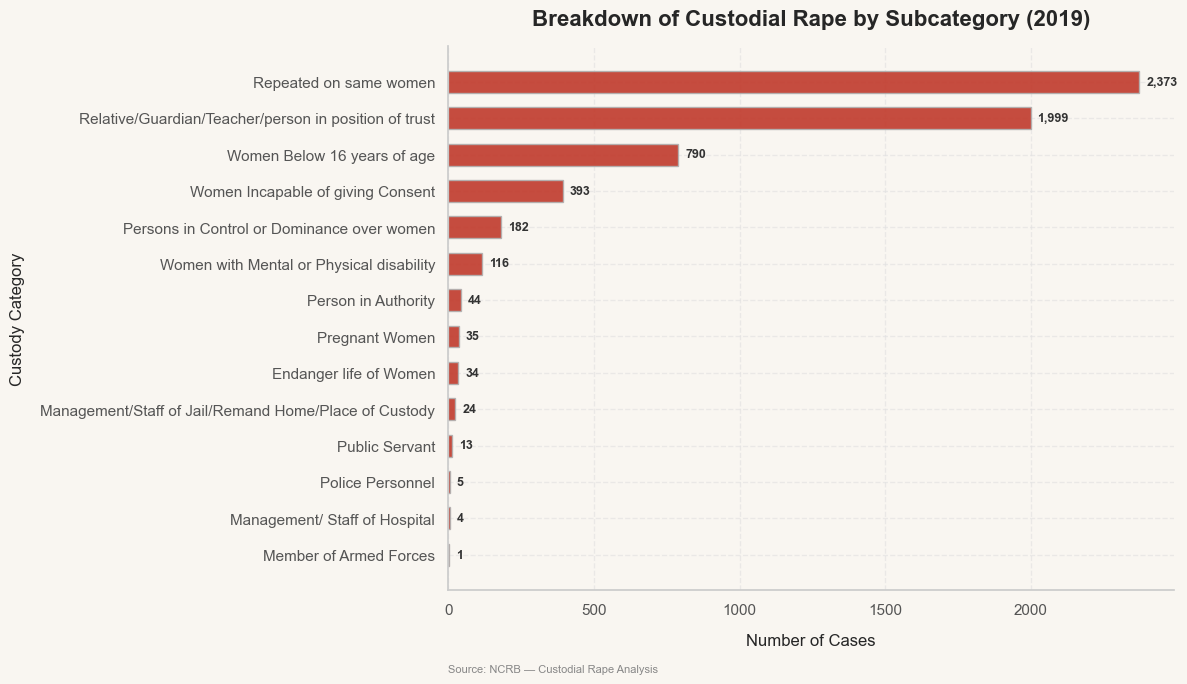

In [18]:
u.set_style()

# Filter for Custodial Rape records and aggregate by custody subcategories
custodial_df = csv7[csv7['Offense_Category'].str.contains("Custodial", case=False, na=False)]
subcat_totals = custodial_df.groupby('Offense_Subcategory')["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    subcat_totals.index,
    subcat_totals.values,
    color="#c0392b",
    height=0.6,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Breakdown of Custodial Rape by Subcategory (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Cases", fontsize=12)
ax.set_ylabel("Custody Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Custodial Rape Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_03_custodial_rape_subcategories.png")
plt.show()

Chart saved- charts/csv7_04_UP_custodial_rape.png


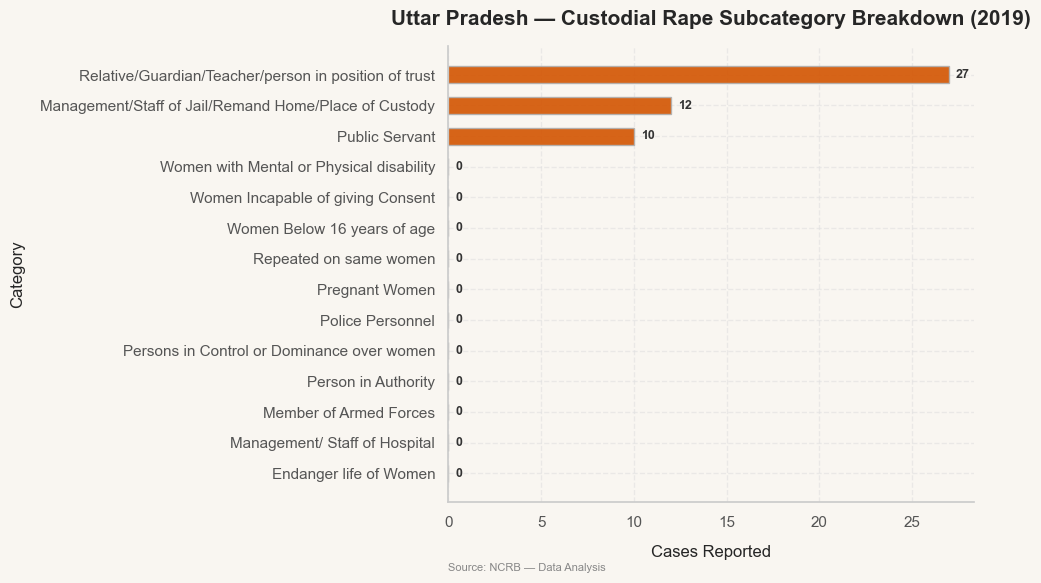

In [19]:
# Filter specifically for Uttar Pradesh custodial rape subcategories
up_custodial = csv7[
    (csv7["State/UT"].str.upper() == "UTTAR PRADESH") & 
    (csv7['Offense_Category'].str.contains("Custodial", case=False, na=False))
]

up_subcats = up_custodial.groupby("Offense_Subcategory")["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    up_subcats.index,
    up_subcats.values,
    color="#d35400",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Uttar Pradesh — Custodial Rape Subcategory Breakdown (2019)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Cases Reported", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Data Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_04_UP_custodial_rape.png")
plt.show()

Chart saved- charts/csv7_05_minor_crimes_bar.png


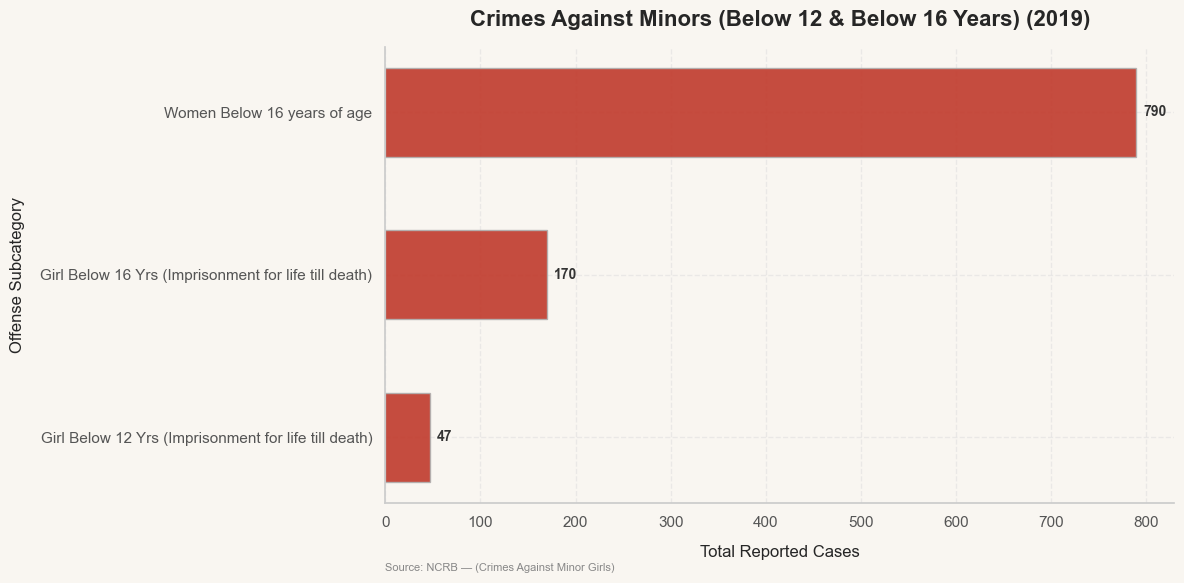

In [20]:
u.set_style()

# Filter specifically for minor protection offense subcategories
minor_categories = [
    "Girl Below 12 Yrs (Imprisonment for life till death)",
    "Girl Below 16 Yrs (Imprisonment for life till death)",
    "Women Below 16 years of age",
]

df_minors = csv7[csv7["Offense_Subcategory"].isin(minor_categories)]


# Aggregate total cases by offense category
category_totals = (
    df_minors.groupby("Offense_Subcategory")['Incidents']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    category_totals.index,
    category_totals.values,
    color="#c0392b",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crimes Against Minors (Below 12 & Below 16 Years) (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Cases", fontsize=12)
ax.set_ylabel("Offense Subcategory", fontsize=12)

# X-axis number formatting
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=10,
      fontweight="bold",
      color="#333333",
  )

u.add_source(
    ax, "NCRB — (Crimes Against Minor Girls)"
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_05_minor_crimes_bar.png")
plt.show()